-------------- Starting Lagrangian Relaxation -------------
Iter. |   λ    |  Lower Bound  |   Upper Bound  |   Gap
-----------------------------------------------------------
    1 | 0.0000 |          -Inf |         3.0000 |       Inf
    2 | 0.5000 |        2.0000 |         2.5000 |     0.500
    3 | 0.1667 |        2.0000 |         2.5000 |     0.500
    4 | 0.4167 |        2.0000 |         2.5000 |     0.500
    5 | 0.6167 |        2.0000 |         2.5000 |     0.500
    6 | 0.4500 |        2.0000 |         2.5000 |     0.500
    7 | 0.5929 |        2.0000 |         2.5000 |     0.500
    8 | 0.4679 |        2.0000 |         2.5000 |     0.500
    9 | 0.5790 |        2.0000 |         2.5000 |     0.500
   10 | 0.4790 |        2.0000 |         2.5000 |     0.500
   11 | 0.5699 |        2.0000 |         2.5000 |     0.500
-----------------------------------------------------------
Lagrangian relaxation stopped. No improvement in UB for 10 iterations.
------------------------- Results

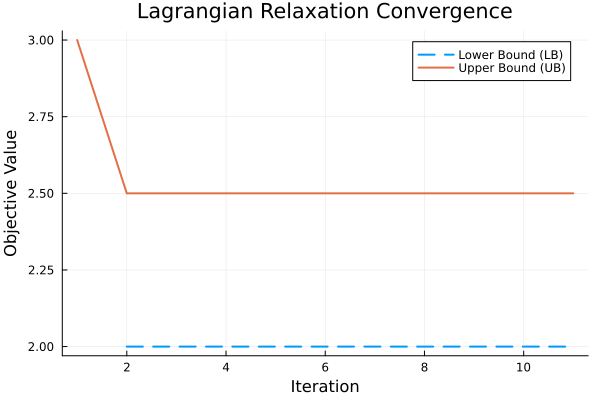

In [ ]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 7 – Lagrangian relaxation
#  Section: Exercise 1.3
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP   # For mathematical programming
using HiGHS  # HiGHS solver
using Printf # For formatted output
using Plots  # For plotting

# Function to solve the original integer program exactly
function solve_exact()
    # Create the model
    model =  JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Define binary variables
    @variable(model, x[1:2], Bin)
    # Define the objective function
    @objective(model, Max, x[1] + 2 * x[2])
    # Define the constraint
    @constraint(model, 2 * x[1] + x[2] <= 2)
    # Solve the model
    JuMP.optimize!(model)
    # Get results
    x_opt =  JuMP.value.(x)
    obj_value = JuMP.objective_value(model)
    return x_opt, obj_value
end

# Function to plot convergence of LB and UB
function plot_convergence(lb_history, ub_history)
    p = plot(1:length(lb_history), [lb_history ub_history],
        label=["Lower Bound (LB)" "Upper Bound (UB)"],
        xlabel="Iteration",
        ylabel="Objective Value",
        title="Lagrangian Relaxation Convergence",
        linewidth=2,
        linestyle=[:dash :solid],
        legend=:topright)
    display(p)
end

# Function to perform Lagrangian relaxation
function solve_lagrangian(iterations = 100)
    # Initialize variables
    x = [0, 0]  # Initial solution
    λ = 0.0     # Initial Lagrange multiplier
    λ_best = λ  # To track the best λ found
    α = 0.1     # Step size
    LB = -Inf   # Best lower bound found so far
    UB = Inf    # Best upper bound found so far
    LB_history = Float64[] # To store LB values for plotting
    UB_history = Float64[] # To store UB values for plotting

    # Logic to stop if no improvement in UB for a certain number of iterations
    no_improve_limit = 10
    no_improve_counter = 0

    println("-------------- Starting Lagrangian Relaxation -------------")
    println("Iter. |   λ    |  Lower Bound  |   Upper Bound  |   Gap")
    println("-"^59)

    for t in 1:iterations
        # Compute primal solution at current λ
        x[1] = (1 - 2λ > 0) ? 1 : 0
        x[2] = (2 - λ > 0) ? 1 : 0

        # Lagrangian dual value
        zL = 2λ + max(0, 1 - 2λ) + max(0, 2 - λ)
        
        # Check for improvement in UB
        if zL < UB 
            UB = zL
            λ_best = λ              # Update the best λ found
            no_improve_counter = 0  # Reset counter if we have an improvement
        else
            no_improve_counter += 1
            # Check if we have reached the limit of no improvement
            if no_improve_counter >= no_improve_limit
                println("-"^59)
                println("Lagrangian relaxation stopped. No improvement in UB for $no_improve_limit iterations.")
                break
            end
        end

        # Feasible primal value
        if 2x[1] + x[2] <= 2
            zP = x[1] + 2x[2]
            LB = max(LB, zP)
        end
        
        # Store LB and UB values for plotting
        push!(LB_history, LB)
        push!(UB_history, UB)

        # Print iteration details
        @printf("%5d | %5.4f | %13.4f | %14.4f | %9.3f\n", t, λ, LB, UB, UB - LB)

        # Subgradient
        g = 2 - (2x[1] + x[2])
        
        # Update step size (Diminishing step size)
        α = 1 / (1 + t)

        # Update λ (project onto λ ≥ 0)
        λ = max(0, λ - α * g)
    end
    return UB, λ_best, LB_history, UB_history
end

# Solve using Lagrangian relaxation
UB, λ_best, LB_history, UB_history = solve_lagrangian()

# Solve exactly to find the optimal value
xO, zO = solve_exact()

println("------------------------- Results -------------------------")
@printf("Optimal Dual Solution (λ = %4.2f): %4.2f\n", λ_best, UB)
@printf("Optimal Primal Solution: x = [%d, %d] with objective value %4.2f\n", xO[1], xO[2], zO)
@printf("Duality gap: %4.2f - %4.2f = %4.2f\n", UB, zO, UB - zO)

# Plot convergence of LB and UB
plot_convergence(LB_history, UB_history)